In [ ]:
from baja.toy_problem import (
    load_cubs_traj_data,
    get_toy_setup_params,
    dynamics_fn,
    log_measurement,
)
import numpy as np
import matplotlib.pyplot as plt
import rerun as rr
from baja import ukf, fpf, pf, GaussianState, ParticleState
import jax.numpy as jnp
import jax.random as jr
import os
import jax

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".20"
jax.config.update("jax_enable_x64", True) # we should use double precision here because floating point error with particles is actually signicant

df = load_cubs_traj_data("0.1s")[:200]
seq_len = len(df)

ts = df.index.to_numpy().astype(np.datetime64)
target_pos = df[["x", "y", "z"]].to_numpy()

sensor_type = "b"
Q, R, meas_fn, sensor_pos = get_toy_setup_params(sensor_type)
meas_dim = R.shape[0]

In [11]:
key = jr.key(42)
rng = np.random.default_rng(12345)


init_state = np.hstack([rng.normal(target_pos[0], size=(3,)), rng.uniform(-1, 1, (3,))])
state_ukf = GaussianState(mean=init_state, cov=Q)

filter_ukf = ukf.UnscentedKalmanFilter(
    f=dynamics_fn,
    h=meas_fn,
    Q=Q,
    R=R,
)

n_particles = 100
init_state = np.hstack(
    [
        rng.normal(target_pos[0], size=(n_particles, 3)),
        rng.uniform(-1, 1, (n_particles, 3)),
    ]
)
state_fpf = ParticleState(init_state, np.ones(n_particles) / n_particles, key)
filter_fpf = fpf.FPF(
    f=dynamics_fn,
    h=meas_fn,
    num_particles=n_particles,
    Q=Q,
    R=R,
    flow_steps=30,
)

n_particles = 1000
init_state = np.hstack(
    [
        rng.normal(target_pos[0], size=(n_particles, 3)),
        rng.uniform(-1, 1, (n_particles, 3)),
    ]
)
state_bpf = ParticleState(init_state, np.ones(n_particles)/ n_particles, key)
filter_bpf = pf.ParticleFilter(
    f=dynamics_fn,
    h=meas_fn,
    num_particles=n_particles,
    Q=Q,
    R=R,
    # flow_steps=50,
)

In [15]:
rr.init("traj_vis")
# rr.connect_grpc()

ukf_hist = []
ukf_hist.append(state_ukf)

fpf_hist = []
fpf_hist.append(state_fpf)

bpf_hist = []
bpf_hist.append(state_bpf)

rr.log(
    "sensors/location",
    rr.Points3D(
        positions=sensor_pos,
        radii=[0.2] * sensor_pos.shape[0],
        labels=np.arange(sensor_pos.shape[0]).astype(str),
    ),
    static=True,
    strict=True,
)
rr.log(
    "traj/line",
    rr.LineStrips3D(strips=target_pos, radii=[0.05], colors=[0x43AAFFC3]),
    static=True,
    strict=True,
)
rr.log(
    "traj/ukf",
    rr.Points3D(
        positions=state_ukf.mean[:3],
        radii=[0.2],
        colors=[(0, 255, 0)],
    ),
)
rr.log("traj/cloud_fpf", rr.Points3D(positions=state_fpf.particles[:, :3]))


for i in range(seq_len):
    rr.set_time("step", sequence=i)
    key, sub_key = jr.split(key)
    true_pos = target_pos[i, :]
    rr.log(
        "traj/true",
        rr.Points3D(positions=true_pos, radii=[0.1], colors=[(255, 0, 0)]),
    )

    meas_noisy = meas_fn(true_pos) + jr.uniform(
        key=sub_key, shape=(meas_dim,), minval=-1, maxval=1
    ) * jnp.sqrt(jnp.diag(R))

    log_measurement(sensor_type, meas_noisy, sensor_pos)

    state_pred_ukf = filter_ukf.predict(state_ukf)
    state_ukf = filter_ukf.update(state_pred_ukf, meas_noisy)
    ukf_hist.append(state_ukf)

    state_fpf, flow_states = filter_fpf.run_step(state_fpf, meas_noisy)
    fpf_hist.append(state_fpf)
    
    state_bpf = filter_bpf.run_step(state_bpf, meas_noisy)
    bpf_hist.append(state_bpf)

    rr.log("traj/ukf", rr.Points3D(positions=state_ukf.mean[:3], radii=[0.2]))
    rr.log("traj/cloud_fpf", rr.Points3D(positions=state_fpf.particles[:, :3]))
    p_flow = flow_states[0][..., :3].transpose(1, 0, 2)
    rr.log(
        "traj/homotopy_flow",
        rr.LineStrips3D(strips=np.array(p_flow), radii=[0.01] * n_particles),
    )
    rr.log("traj/cloud_bpf", rr.Points3D(positions=state_bpf.particles[:, :3]))
    

rr.notebook_show(width=960, height=720)

HTML(value='<div id="d295d5b4-e913-4f0c-ba5e-79da133f9a0f"><style onload="eval(atob(\'KGFzeW5jIGZ1bmN0aW9uICgp…

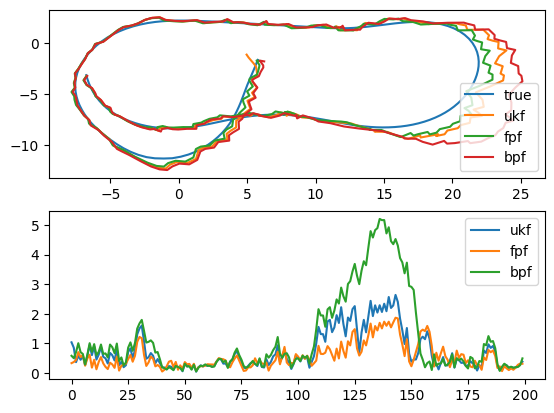

In [16]:
ukf_est = np.array([s.mean for s in ukf_hist])
fpf_est = np.array([s.mean for s in fpf_hist])
bpf_est = np.array([s.mean for s in bpf_hist])

fig = plt.figure()
axs = fig.subplots(2,1).flatten()
axs[0].plot(target_pos[:, 0], target_pos[:, 1], label='true')
axs[0].plot(ukf_est[1:,0], ukf_est[1:, 1], label='ukf')
axs[0].plot(fpf_est[1:,0], fpf_est[1:, 1], label='fpf')
axs[0].plot(bpf_est[1:,0], bpf_est[1:, 1], label='bpf')

axs[0].legend()
axs[1].plot(np.linalg.norm(ukf_est[1:,:3] - target_pos, axis=1), label='ukf')
axs[1].plot(np.linalg.norm(fpf_est[1:,:3] - target_pos, axis=1), label='fpf')
axs[1].plot(np.linalg.norm(bpf_est[1:,:3] - target_pos, axis=1), label='bpf')
axs[1].legend()

In [12]:
import jax
h = meas_fn
h_vmap = jax.vmap(h)
h_hat = jnp.mean(h_vmap(init_state), axis=0)
h_var = jnp.var(h_vmap(init_state))
# h_hat, h_var
dh2 = jnp.mean(jnp.sum(h_vmap(init_state) ** 2, axis=1))
dh2, jnp.linalg.norm(h_hat)**2, jnp.var(h_vmap(init_state))



(Array(0.58947161, dtype=float64),
 Array(0.57582248, dtype=float64),
 Array(0.07893489, dtype=float64))

In [13]:
z_pred = h_vmap(init_state)
R_inv = np.linalg.inv(R)

h_hat @ R_inv @ h_hat, jnp.mean(jnp.sum(((z_pred @ R_inv) * z_pred), axis=1)), jnp.mean(jnp.array([z @ R_inv @ z for z in z_pred])), jnp.mean(jax.vmap(lambda z: z @ R_inv @ z)(z_pred)), np.mean(np.array([z @ R_inv @ z for z in z_pred]))

(Array(472.57842638, dtype=float64),
 Array(483.7802838, dtype=float64),
 Array(483.7802838, dtype=float64),
 Array(483.7802838, dtype=float64),
 np.float64(483.780283797244))

In [14]:
S_bar = jnp.mean(init_state[:, :3], axis=0)

S_bar[:, None] @ (R_inv @ jnp.sum(z_pred - h_hat, axis=0))[None], np.sum(z_pred - h_hat, axis=0)

(Array([[ 2.88753089e-10,  8.52835013e-11, -7.31753499e-11,
          5.26441366e-12],
        [-7.89097423e-11, -2.33060679e-11,  1.99971817e-11,
         -1.43864617e-12],
        [ 1.16011167e-10,  3.42640093e-11, -2.93993660e-11,
          2.11506230e-12]], dtype=float64),
 Array([ 6.08957329e-14,  1.79856130e-14, -1.54321000e-14,  1.11022302e-15],      dtype=float64))